<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%207/cifar_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Training a CNN on CIFAR-10

**Goal:** Train the convolutional network on **CIFAR-10** — 60,000 tiny 32×32 color photos across 10 real-world classes. This is a big step up from MNIST.

### Why CIFAR-10 is harder than MNIST

| | MNIST | CIFAR-10 |
|---|---|---|
| Content | handwritten digits | real objects (planes, cats, ships…) |
| Color | grayscale (1 channel) | RGB (3 channels) |
| Size | 28×28 | 32×32 |
| Background | clean/black | real, cluttered |
| Variation | low | high (pose, lighting, scale) |
| MLP accuracy | ~98% | ~45-50% |
| Basic CNN | ~99% | ~70% |

The huge within-class variation (a cat can appear a thousand ways) is exactly why spatial structure and convolutions matter here far more than for centered digits.

---

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

%matplotlib inline

## 1. Load CIFAR-10

We convert images to tensors with `ToTensor()` (which also scales pixel values to [0, 1]). The download is ~170 MB and cached after the first run, so re-running is fast.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train = torchvision.datasets.CIFAR10(root='./data', train=True,  transform=transform, download=True)
test  = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

trainloader = DataLoader(train, batch_size=64, shuffle=True)
testloader  = DataLoader(test,  batch_size=64, shuffle=False)   # NOTE: test set, not train!

100%|██████████| 170M/170M [1:09:23<00:00, 41.0kB/s]


### Visualize a few images

See what we're working with — real objects at low resolution.

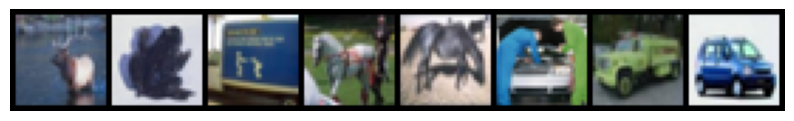

Labels: deer | frog | truck | horse | horse | automobile | truck | automobile


In [ ]:
def imshow(img):
    npimg = img.numpy()
    # matplotlib wants (H, W, C); tensors are (C, H, W)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 3))
imshow(torchvision.utils.make_grid(images[:8]))
plt.show()
print('Labels:', ' | '.join(classes[labels[j]] for j in range(8)))

---
## 2. The CNN

Same `[Conv → ReLU → Pool]` pattern as the MNIST CNN, adapted for CIFAR:
- **First conv takes 3 input channels** (RGB) instead of 1.
- **Input is 32×32**, which changes the flatten size.

### Tracing the shapes (starting from `(3, 32, 32)`)

| Layer | Operation | Output |
|---|---|---|
| Input | — | (3, 32, 32) |
| Conv2d(3, 32, 3) | 32 − 3 + 1 = 30 | (32, 30, 30) |
| MaxPool2d(2, 2) | 30 / 2 = 15 | (32, 15, 15) |
| Conv2d(32, 64, 3) | 15 − 3 + 1 = 13 | (64, 13, 13) |
| MaxPool2d(2, 2) | 13 / 2 = 6 (floor!) | (64, 6, 6) |
| Flatten | 64 × 6 × 6 | 2304 |
| Linear(2304, 10) | — | 10 |

Note the **13 / 2 = 6** step floors — 13 is odd, so pooling drops the remainder. Writing the Linear as `64*6*6` documents where the 2304 comes from.

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Conv2d(3, 32, 3),    # (3,32,32)  -> (32,30,30)
        nn.ReLU(),
        nn.MaxPool2d(2, 2),     # (32,30,30) -> (32,15,15)
        nn.Conv2d(32, 64, 3),   # (32,15,15) -> (64,13,13)
        nn.ReLU(),
        nn.MaxPool2d(2, 2),     # (64,13,13) -> (64,6,6)
        nn.Flatten(),           # -> 64*6*6 = 2304
        nn.Linear(64 * 6 * 6, 10)
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
# Sanity-check the forward pass BEFORE training
cnn = CNN()
sample = torch.randn(64, 3, 32, 32)     # a fake CIFAR batch
print("Output shape:", cnn(sample).shape)  # expect (64, 10)

Output shape: torch.Size([64, 10])


---
## 3. Train

We use **Adam** (`lr=1e-3`) — it converges faster than plain SGD here. CIFAR needs more epochs than MNIST to learn its harder patterns; ~10-15 is a reasonable start. We print the average loss each epoch so we can watch it fall.

In [ ]:
cnn = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

EPOCHS = 12

for epoch in range(EPOCHS):
    cnn.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        optimizer.zero_grad()
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1:2d}/{EPOCHS}: avg loss {running_loss / len(trainloader):.3f}")

print("Finished Training")

Epoch  1/12: avg loss 1.576
Epoch  2/12: avg loss 1.291
Epoch  3/12: avg loss 1.164
Epoch  4/12: avg loss 1.077
Epoch  5/12: avg loss 1.022
Epoch  6/12: avg loss 0.973
Epoch  7/12: avg loss 0.942
Epoch  8/12: avg loss 0.912
Epoch  9/12: avg loss 0.886
Epoch 10/12: avg loss 0.862
Epoch 11/12: avg loss 0.845
Epoch 12/12: avg loss 0.824
Finished Training


---
## 4. Evaluate on the Test Set

The real measure of the model: accuracy on data it never trained on. We use `torch.no_grad()` (no gradients needed for evaluation) and `argmax` to turn the 10 class scores into a predicted label.

In [ ]:
correct = 0
total = 0

cnn.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = cnn(images)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 67.95%


### Per-class accuracy — where does it struggle?

Overall accuracy hides which classes are hard. Breaking it down per class is basic **error analysis** — it reveals, for example, that cats and dogs are often confused (both furry, four-legged, similar poses), while ships and trucks are easier (distinct shapes).

In [ ]:
class_correct = [0] * 10
class_total   = [0] * 10

cnn.eval()
with torch.no_grad():
    for images, labels in testloader:
        preds = torch.argmax(cnn(images), dim=1)
        for label, pred in zip(labels, preds):
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1

for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:12s}: {acc:.1f}%")

airplane    : 69.0%
automobile  : 81.4%
bird        : 50.7%
cat         : 46.8%
deer        : 63.8%
dog         : 59.2%
frog        : 86.5%
horse       : 65.7%
ship        : 76.8%
truck       : 79.6%


### See some predictions

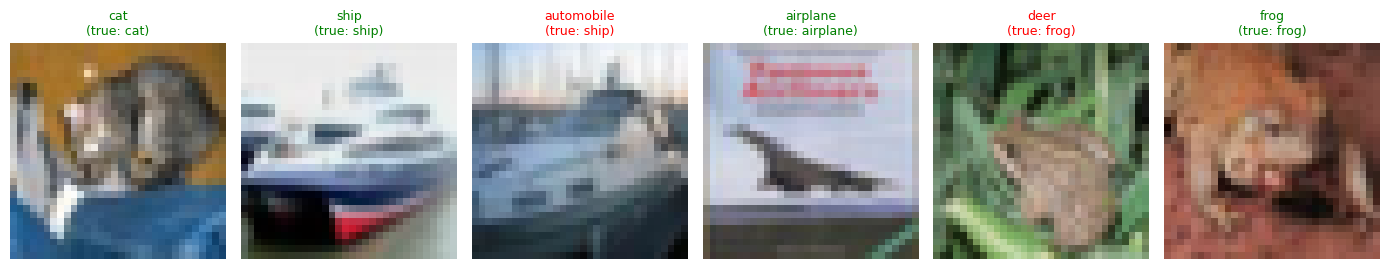

In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

cnn.eval()
with torch.no_grad():
    preds = torch.argmax(cnn(images), dim=1)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for k, ax in enumerate(axes):
    ax.imshow(np.transpose(images[k].numpy(), (1, 2, 0)))
    correct_pred = preds[k] == labels[k]
    color = 'green' if correct_pred else 'red'
    ax.set_title(f"{classes[preds[k]]}\n(true: {classes[labels[k]]})", color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Optional — Boosting Accuracy with Data Augmentation

**Data augmentation** creates more training variety for free by randomly transforming images — a horizontally flipped cat is still a cat, so the model learns to be robust to it. Adding random flips and crops often adds several points of accuracy and reduces overfitting.

To use it, rebuild the training set with an augmenting transform and retrain:

```python
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])
# test transform stays plain ToTensor() — never augment the test set
```

Note: augmentation is applied **only to training data**, never to the test set — you evaluate on clean images.

---

## Summary

| Step | Detail |
|---|---|
| Dataset | CIFAR-10: 32×32 RGB, 10 classes |
| Architecture | 2× [Conv→ReLU→Pool] → Flatten → Linear |
| Flatten size | 64 × 6 × 6 = 2304 (traced from 32×32 input) |
| Optimizer | Adam, lr=1e-3 |
| Evaluation | on the **test** set, with per-class breakdown |

**Key lessons:** CIFAR is much harder than MNIST because of color, real backgrounds, and within-class variation — which is exactly why CNNs (spatial structure, translation invariance) matter here. Per-class accuracy is a first taste of error analysis, and data augmentation is a cheap way to squeeze out more performance.

**Next: ResNet blocks and skip connections — how very deep networks train.**